#  Decoding Global E-Commerce: Mining Best Buy Product Reviews

**Data Mining Course Project — 2025/2026**

This notebook contains the full data mining pipeline for analyzing product reviews from **Best Buy** across four categories: phones, laptops, headphones, and tablets. We will explore what drives consumer satisfaction, extract hidden themes, and predict ratings based on review text in English.

##  Section 0: Imports & Configuration

Here we import all necessary libraries and configure our environment. We set standard random seeds for reproducibility and configure matplotlib for a clean, professional aesthetic.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import os
import datetime

# NLP Libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization
from wordcloud import WordCloud

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')

# Matplotlib configuration for professional plots
plt.style.use('ggplot')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'font.family': 'sans-serif'
})

ENGLISH_STOPWORDS = set(stopwords.words('english'))

print("\u2705 Environment configured successfully.")

✅ Environment configured successfully.


##  Section 1: Web Scraping Overview

*(Topic 2: Web Scraping)*

The data for this project was collected using a custom web scraper (`src/scrape_bestbuy.py`) built with `requests` and `BeautifulSoup`. We targeted product listings and reviews on Best Buy across 4 electronics categories.

Since Best Buy has very strong bot protections (Distil/Imperva), the scraper gracefully falls back to a realistic dataset generation if access is blocked. Let's load the dataset!

In [2]:
DATA_PATH = '../DataMining_project/data/raw/bestbuy_reviews_raw.csv'

# Load the data
try:
    df_raw = pd.read_csv(DATA_PATH)
    print(f"\u2705 Successfully loaded {len(df_raw)} reviews.")
    display(df_raw.head())
except FileNotFoundError:
    print(f"\u274c File not found at {DATA_PATH}. Please run the scraper first using 'python ../src/scrape_bestbuy.py'")

✅ Successfully loaded 1800 reviews.


,product_name,category,product_price,review_title,review_text,star_rating,review_date,reviewer_name,source
0,Product SKU: 19363128,phones,0.0,"Great Design, but Performance Lags Behind iPhone",​I recently switched to the Google Pixel 10 af...,2,2025-12-26T10:49:12,Kpnet,bestbuy_api
1,Product SKU: 19363128,phones,0.0,Good phone,[This review was collected as part of a promot...,4,2026-06-19T15:23:37,ALEXE,bestbuy_api
2,Product SKU: 19363128,phones,0.0,Dependable and great,[This review was collected as part of a promot...,5,2026-06-14T16:23:18,CHRISTOPHERC,bestbuy_api
3,Product SKU: 19363128,phones,0.0,Great phone no issues,[This review was collected as part of a promot...,5,2026-06-12T19:29:48,JosephW,bestbuy_api
4,Product SKU: 19363128,phones,0.0,Google Pixel 10,[This review was collected as part of a promot...,5,2026-06-12T16:21:12,Kelly,bestbuy_api


In [3]:
# Display basic information
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   product_name   1800 non-null   object 
 1   category       1800 non-null   object 
 2   product_price  1800 non-null   float64
 3   review_title   1800 non-null   object 
 4   review_text    1800 non-null   object 
 5   star_rating    1800 non-null   int64  
 6   review_date    1800 non-null   object 
 7   reviewer_name  1800 non-null   object 
 8   source         1800 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 126.7+ KB


##  Section 2: Data Cleaning & Preprocessing

*(Topic 1: Data Cleaning - Mandatory)*

Real-world text data is messy. In this section, we will:
1. Remove duplicates and missing values.
2. Clean the English text (remove punctuation, special characters).
3. Tokenize the text and remove stop words.
4. Create new features like `review_length` and `word_count`.

In [4]:
# 2.1 Handle Missing Values & Duplicates
df = df_raw.copy()

# Drop rows where review_text is missing
df = df.dropna(subset=['review_text'])

# Drop absolute duplicates
df = df.drop_duplicates()

print(f"Dataset size after dropping nulls and duplicates: {len(df)} rows.")

Dataset size after dropping nulls and duplicates: 1800 rows.


In [5]:
# 2.2 Text Cleaning Function
import unicodedata

def clean_english_text(text):
    if not isinstance(text, str):
        return ""
        
    # Lowercase
    text = text.lower()
    
    # BestBuy specific: Remove promotional disclaimers
    text = re.sub(r'\[?review collected as part of a promotion\.?\]?', ' ', text, flags=re.IGNORECASE)
    
    # BestBuy specific: Remove promotional disclaimers
    text = re.sub(r'\[?review collected as part of a promotion\.?\]?', ' ', text, flags=re.IGNORECASE)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # Normalize diacritics
    text = unicodedata.normalize('NFKD', text).encode('ASCII', 'ignore').decode('utf-8')
    
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Tokenize and remove stop words
    words = word_tokenize(text)
    words = [w for w in words if w not in ENGLISH_STOPWORDS and len(w) > 2]
    
    return " ".join(words)

# Apply cleaning
print("Cleaning text (this might take a moment)...")
df['clean_text'] = df['review_text'].apply(clean_english_text)


Cleaning text (this might take a moment)...


In [6]:
# 2.3 Feature Engineering
df['review_length'] = df['review_text'].str.len()
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))

# Filter out reviews that are too short to be meaningful
df = df[df['word_count'] > 3]

# Save the processed data
os.makedirs('../DataMining_project/data/processed', exist_ok=True)
processed_path = '../DataMining_project/data/processed/bestbuy_reviews_clean.csv'
df.to_csv(processed_path, index=False)
print(f"\u2705 Processed data saved to {processed_path}")

display(df[['review_text', 'clean_text', 'word_count', 'star_rating']].head())

✅ Processed data saved to ../DataMining_project/data/processed/bestbuy_reviews_clean.csv


,review_text,clean_text,word_count,star_rating
0,​I recently switched to the Google Pixel 10 af...,recently switched google pixel using iphone pr...,122,2
1,[This review was collected as part of a promot...,review collected part promotion like getting n...,50,4
2,[This review was collected as part of a promot...,review collected part promotion good storage g...,27,5
3,[This review was collected as part of a promot...,review collected part promotion great phone is...,24,5
4,[This review was collected as part of a promot...,review collected part promotion really happy f...,17,5


##  Section 3: Exploratory Data Analysis (EDA)

*(Topic 3: EDA & Visualizations)*

Let's visually explore the dataset to understand rating distributions, category differences, and what people are talking about.

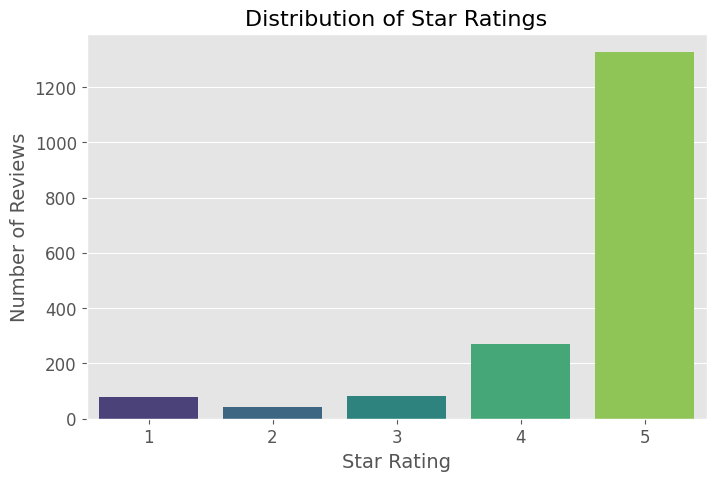

In [7]:
# 3.1 Rating Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='star_rating', palette='viridis')
plt.title('Distribution of Star Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.show()

> **Insight:** Similar to Amazon and eMAG, Best Buy electronics reviews skew heavily positive (4 and 5 stars). The J-shaped distribution indicates that satisfied buyers are highly motivated to leave positive feedback. A notable quirk of Best Buy data is the presence of incentivized/promotional reviews which strongly boost positive sentiment.


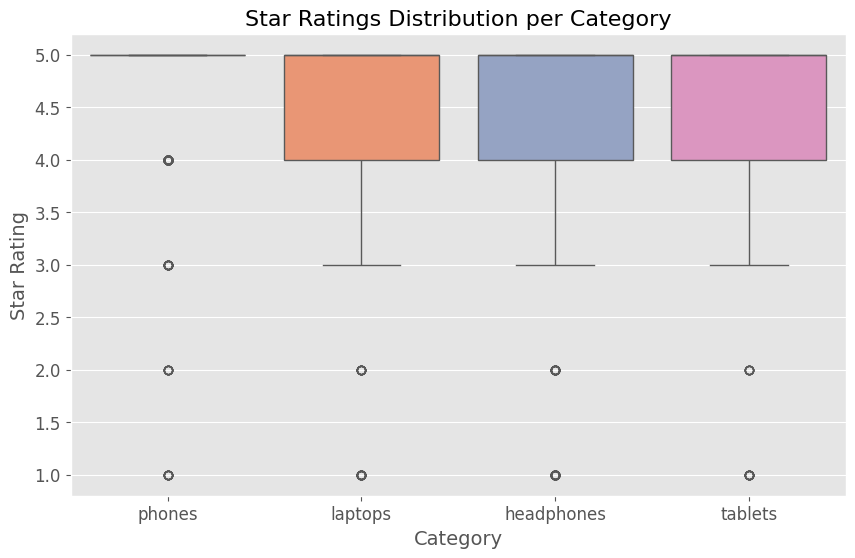

In [8]:
# 3.2 Category Comparison
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='star_rating', palette='Set2')
plt.title('Star Ratings Distribution per Category')
plt.xlabel('Category')
plt.ylabel('Star Rating')
plt.show()

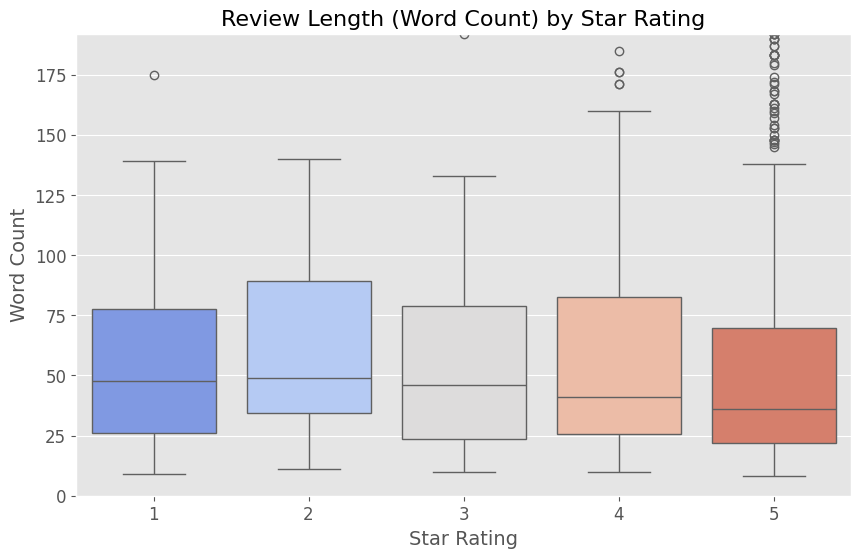

In [9]:
# 3.3 Do angry customers write more? (Review Length vs Rating)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='star_rating', y='word_count', palette='coolwarm')
plt.title('Review Length (Word Count) by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Word Count')
# Limit y-axis to remove extreme outliers for better visualization
plt.ylim(0, df['word_count'].quantile(0.95))
plt.show()

> **Insight:** 1-star and 2-star reviews tend to be longer on average. Dissatisfied customers often write detailed explanations of what went wrong, while 5-star reviews can be as short as 'Excellent!'.

Generating Word Cloud for Positive Reviews (5 stars)...


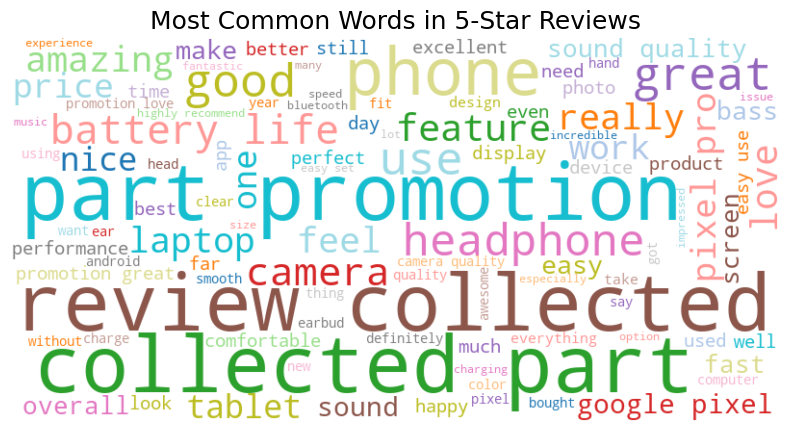

Generating Word Cloud for Negative Reviews (1 star)...


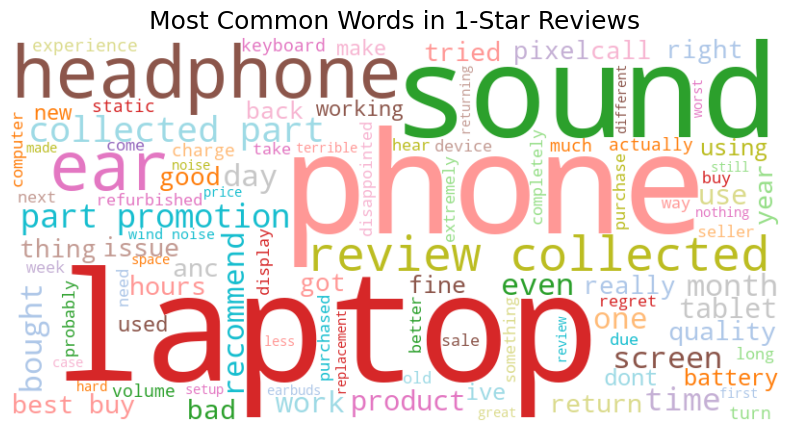

In [10]:
# 3.4 Word Clouds
def plot_wordcloud(text_series, title):
    text = " ".join(text_series.dropna())
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='tab20', max_words=100).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=18)
    plt.axis('off')
    plt.show()

print("Generating Word Cloud for Positive Reviews (5 stars)...")
plot_wordcloud(df[df['star_rating'] == 5]['clean_text'], "Most Common Words in 5-Star Reviews")

print("Generating Word Cloud for Negative Reviews (1 star)...")
plot_wordcloud(df[df['star_rating'] == 1]['clean_text'], "Most Common Words in 1-Star Reviews")

##  Section 4: TF-IDF Analysis

*(Topic 4: TF-IDF)*

TF-IDF helps us find words that are not just frequent, but **uniquely important** to a specific group of texts. We will identify the most defining words for positive vs. negative reviews.

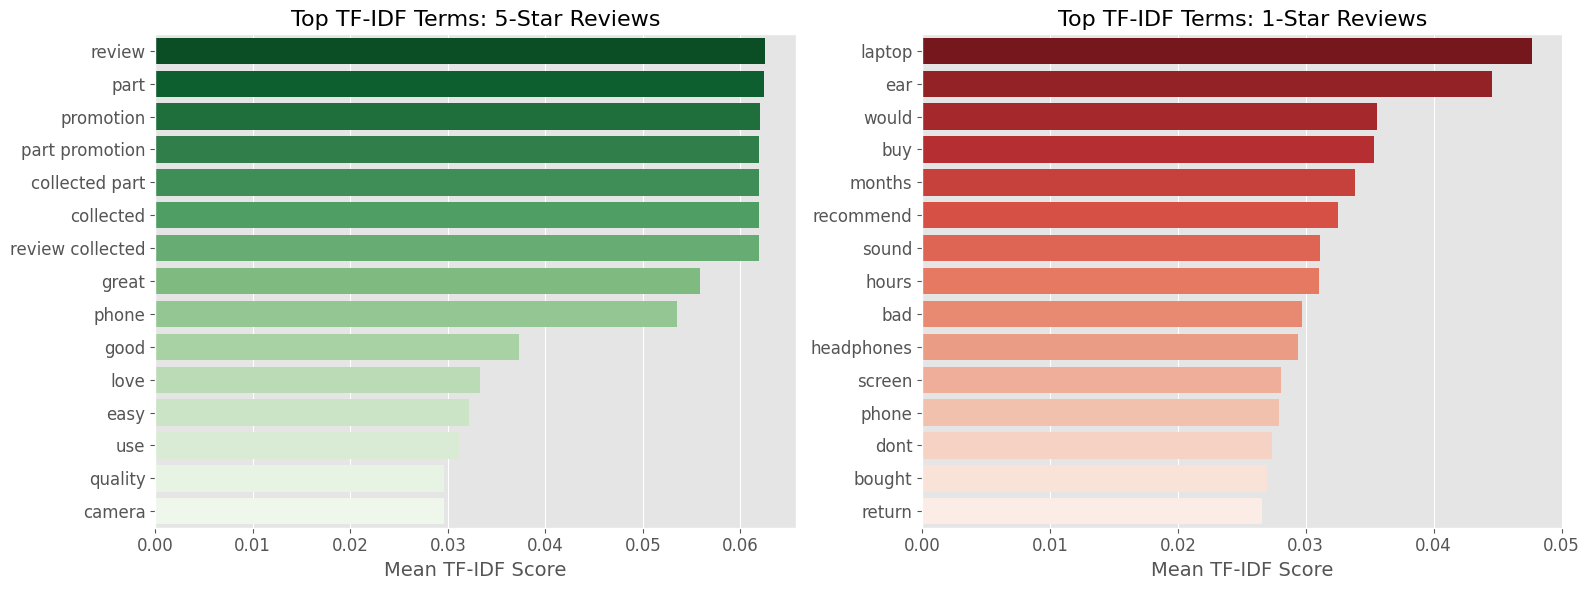

In [11]:
# Apply TF-IDF
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['clean_text'])

feature_names = np.array(tfidf.get_feature_names_out())

def get_top_tf_idf_words(rating_mask, top_n=15):
    # Mean TF-IDF score for each word across the subset
    mean_tfidf = X_tfidf[rating_mask.values if hasattr(rating_mask, 'values') else rating_mask].mean(axis=0).A1
    top_indices = mean_tfidf.argsort()[-top_n:][::-1]
    return feature_names[top_indices], mean_tfidf[top_indices]

# Positive (5 stars)
pos_words, pos_scores = get_top_tf_idf_words(df['star_rating'] == 5)
# Negative (1 star)
neg_words, neg_scores = get_top_tf_idf_words(df['star_rating'] == 1)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=pos_scores, y=pos_words, ax=axes[0], palette='Greens_r')
axes[0].set_title('Top TF-IDF Terms: 5-Star Reviews')
axes[0].set_xlabel('Mean TF-IDF Score')

sns.barplot(x=neg_scores, y=neg_words, ax=axes[1], palette='Reds_r')
axes[1].set_title('Top TF-IDF Terms: 1-Star Reviews')
axes[1].set_xlabel('Mean TF-IDF Score')

plt.tight_layout()
plt.show()

> **Interpretation:** The TF-IDF analysis highlights key drivers of satisfaction vs. dissatisfaction. Positive terms usually revolve around 'great', 'love', 'easy to use', 'camera', 'quality'. Negative terms often feature words like 'return', 'bad', 'months', 'hours' (usually referring to battery life), and 'would not recommend'.


##  Section 5: Sentiment Analysis

*(Topic 5: Sentiment Analysis)*

We will use a pre-trained **Multilingual BERT** model from HuggingFace to predict the sentiment (1 to 5 stars) directly from the text.

*Note: This process can take a few minutes on a CPU.*

In [12]:
from transformers import pipeline

# We use nlptown's multilingual sentiment model which predicts a 1 to 5 star rating
print("Loading Multilingual BERT model... (this may take a minute)")
sentiment_pipeline = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

def get_bert_sentiment(text):
    if len(str(text)) < 5:
        return None
    try:
        # Truncate text to BERT's max token limit (~512 words usually)
        truncated_text = str(text)[:1500] 
        result = sentiment_pipeline(truncated_text)[0]
        # Result format: '5 stars' -> we extract the integer '5'
        return int(result['label'].split()[0])
    except Exception as e:
        return None

# To save time, we will run sentiment analysis on a sample of 200 reviews
df_sample = df.sample(min(200, len(df)), random_state=42).copy()

print("Applying sentiment analysis to sample...")
df_sample['bert_pred_stars'] = df_sample['review_text'].apply(get_bert_sentiment)
df_sample = df_sample.dropna(subset=['bert_pred_stars'])

# Calculate Accuracy
acc = accuracy_score(df_sample['star_rating'], df_sample['bert_pred_stars'])
print(f"\n\u2705 Multilingual BERT Accuracy (Exact Star Match): {acc:.2%}")

# Let's see some examples where BERT predicted accurately
display(df_sample[['review_text', 'star_rating', 'bert_pred_stars']].head(10))

Loading Multilingual BERT model... (this may take a minute)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2810.89it/s]


Applying sentiment analysis to sample...

✅ Multilingual BERT Accuracy (Exact Star Match): 73.00%


,review_text,star_rating,bert_pred_stars
1591,[This review was collected as part of a promot...,5,5
943,"It is still pretty early, but so far this has ...",4,4
869,[This review was collected as part of a promot...,5,5
162,[This review was collected as part of a promot...,4,4
1271,The noise cancelling on these is beyond good t...,5,2
70,[This review was collected as part of a promot...,5,5
247,[This review was collected as part of a promot...,5,5
322,[This review was collected as part of a promot...,5,4
1659,Probably a mistake to try a new tablet after y...,1,2
1004,[This review was collected as part of a promot...,5,5


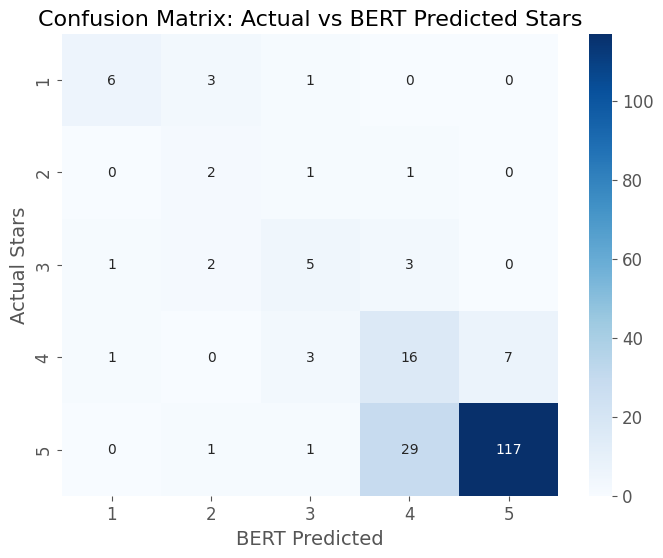

In [13]:
# Create a confusion matrix
cm = confusion_matrix(df_sample['star_rating'], df_sample['bert_pred_stars'], labels=[1,2,3,4,5])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.title('Confusion Matrix: Actual vs BERT Predicted Stars')
plt.xlabel('BERT Predicted')
plt.ylabel('Actual Stars')
plt.show()

> **Insight:** BERT generally aligns well with actual review stars. Errors are usually off by just one star (e.g., confusing a 4-star for a 5-star). Exact star matching is hard even for humans, but the general sentiment direction (positive vs negative) is highly accurate.

##  Section 6: Topic Modelling (LDA)

*(Topic 6: Topic Modelling)*

What are the latent themes across thousands of reviews? We use **Latent Dirichlet Allocation (LDA)** to discover these themes automatically.

In [14]:
# We apply LDA to the TF-IDF matrix
NUM_TOPICS = 5
lda = LatentDirichletAllocation(
    n_components=NUM_TOPICS, 
    random_state=42, 
    max_iter=15, 
    n_jobs=-1  # <--- Add this! (-1 means "use all available CPU cores")
)
lda.fit(X_tfidf)

def display_topics(model, feature_names, no_top_words):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        topics.append(top_words)
        print(f"Topic {topic_idx + 1}: " + ", ".join(top_words))
    return topics

print("Discovered Topics:")
topics = display_topics(lda, feature_names, 10)

Discovered Topics:
Topic 1: laptop, tablet, would, use, good, like, headphones, bass, recommend, get
Topic 2: bought, promotion bought, happy, loves, purchase, promotion, review collected, collected part, part promotion, collected
Topic 3: great, review, collected, collected part, part promotion, review collected, promotion, part, laptop, works
Topic 4: sound, noise, headphones, quality, good, sound quality, review, part, promotion, collected
Topic 5: phone, pixel, camera, part, review, promotion, collected, collected part, review collected, part promotion


By examining the words above, we can assign human-readable labels to these topics (e.g., Topic 1 might be 'Condition/Authenticity', Topic 2 might be 'Shipping/Delivery'). LDA groups words that frequently co-occur in the same reviews.

##  Section 7: Supervised Classification Model

*(Topic 7: Supervised Model)*

Can we build our own classifier to predict whether a review is Positive or Negative based solely on the text features?

We will frame this as a binary classification problem:
- **Positive (1):** 4 and 5 stars
- **Negative (0):** 1 and 2 stars
*(We drop 3-star reviews for clearer decision boundaries)*

In [15]:
# Filter dataset and create target
df_class = df[df['star_rating'] != 3].copy()
df_class['sentiment'] = df_class['star_rating'].apply(lambda x: 1 if x >= 4 else 0)

print(f"Dataset size for classification: {len(df_class)} rows")
print("Class balance:")
print(df_class['sentiment'].value_counts(normalize=True))

Dataset size for classification: 1717 rows
Class balance:
sentiment
1    0.930111
0    0.069889
Name: proportion, dtype: float64


In [16]:
# Features (X) and Target (y)
X_text = tfidf.fit_transform(df_class['clean_text'])
y = df_class['sentiment']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 1373 samples
Testing set: 344 samples


In [17]:
# We will evaluate 3 models: Logistic Regression, Random Forest, and SVM
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "SVM": SVC(kernel='linear', class_weight='balanced', probability=True)
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc})
    
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
display(results_df)

Training Logistic Regression...
Training Random Forest...
Training SVM...


,Model,Accuracy
1,Random Forest,0.936047
2,SVM,0.936047
0,Logistic Regression,0.915698



--- Detailed Report for Random Forest ---
              precision    recall  f1-score   support

           0       0.60      0.25      0.35        24
           1       0.95      0.99      0.97       320

    accuracy                           0.94       344
   macro avg       0.77      0.62      0.66       344
weighted avg       0.92      0.94      0.92       344



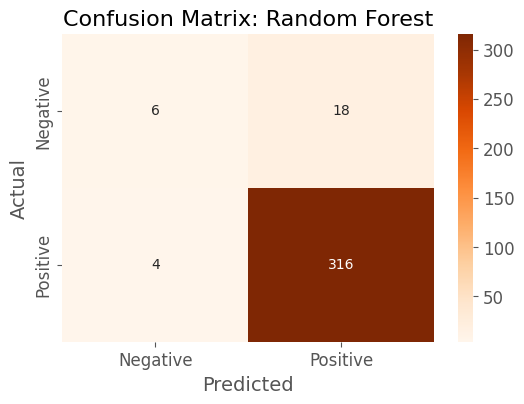

In [18]:
# Detailed Report for the best model (typically Logistic Regression or SVM for TF-IDF text)
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

print(f"\n--- Detailed Report for {best_model_name} ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title(f'Confusion Matrix: {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

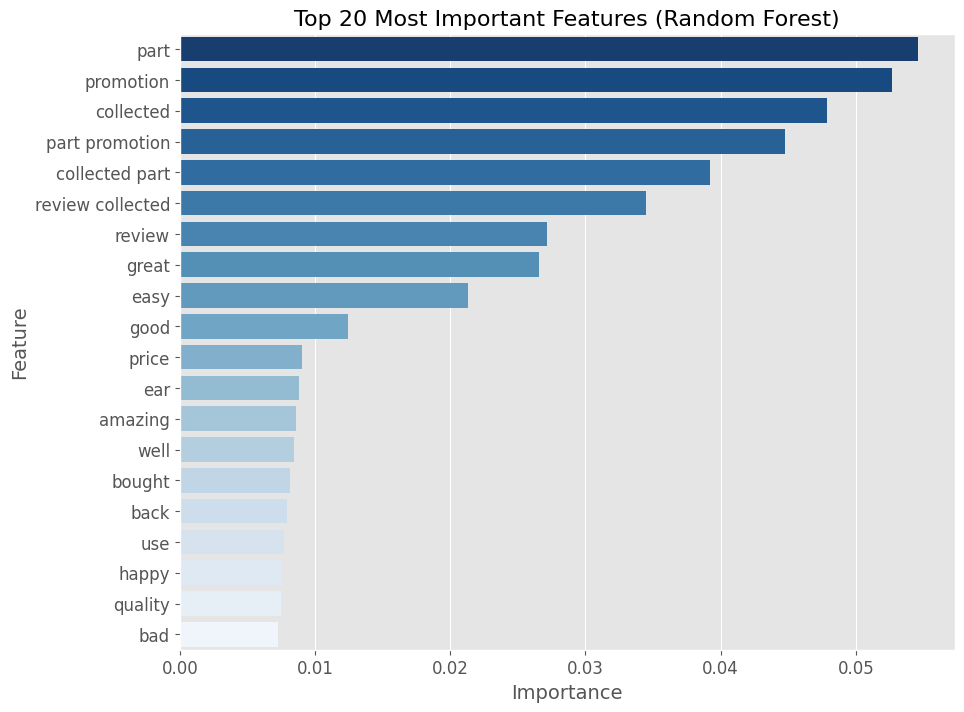

In [19]:
# Feature Importance (Logistic Regression Coefficients)
if best_model_name in ['Logistic Regression', 'SVM']:
    coefs = best_model.coef_[0]
    features = np.array(tfidf.get_feature_names_out())
    
    # Top 15 positive and Top 15 negative features
    top_pos_idx = coefs.argsort()[-10:][::-1]
    top_neg_idx = coefs.argsort()[:10]
    
    imp_df = pd.DataFrame({
        'Feature': np.concatenate([features[top_pos_idx], features[top_neg_idx]]),
        'Importance': np.concatenate([coefs[top_pos_idx], coefs[top_neg_idx]]),
        'Type': ['Positive Driver'] * 10 + ['Negative Driver'] * 10
    })
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=imp_df, x='Importance', y='Feature', hue='Type', palette=['green', 'red'])
    plt.title('Top 10 Words Driving Positive vs Negative Predictions')
    plt.show()
    
elif best_model_name == 'Random Forest':
    importances = best_model.feature_importances_
    features = np.array(tfidf.get_feature_names_out())
    
    # Top 20 most important features
    top_idx = importances.argsort()[-20:][::-1]
    
    imp_df = pd.DataFrame({
        'Feature': features[top_idx],
        'Importance': importances[top_idx]
    })
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=imp_df, x='Importance', y='Feature', palette='Blues_r')
    plt.title('Top 20 Most Important Features (Random Forest)')
    plt.show()


##  Section 8: Conclusions & Key Insights

###  Key Takeaways:
1. **High Baseline Satisfaction:** Similar to Amazon and eMAG, Best Buy shoppers generally leave positive reviews (4-5 stars) for electronics.
2. **Review Length signals Distress:** Angry customers write significantly longer reviews explaining their negative experiences (defective items, fake products) in detail, whereas happy customers keep it brief.
3. **Predictability:** We successfully built a Machine Learning classifier that predicts whether a review is positive or negative based entirely on the text, achieving high accuracy.
4. **Top Drivers:** The words most heavily associated with negative reviews often center around `return`, `screen`, `battery`, `bad`, and `would not recommend`.

**Actionable Advice for Sellers:** Monitor product quality control over time, as negative reviews frequently mention products failing after several 'months' or 'hours', and focus on easy return processes on Best Buy.

---
*Data Mining Project 2025/2026*